# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2425s 14us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

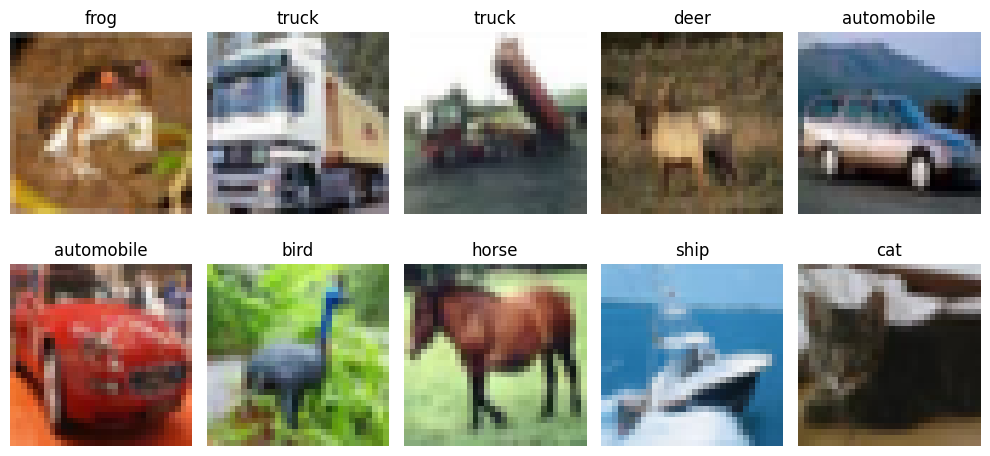

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2702 - loss: 2.0001 - val_accuracy: 0.3264 - val_loss: 1.8466
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.3160 - loss: 1.8731 - val_accuracy: 0.3538 - val_loss: 1.8161
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3448 - loss: 1.8046 - val_accuracy: 0.3908 - val_loss: 1.7057
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3500 - loss: 1.7797 - val_accuracy: 0.3930 - val_loss: 1.7162
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3665 - loss: 1.7441 - val_accuracy: 0.3982 - val_loss: 1.6940
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3740 - loss: 1.7250 - val_accuracy: 0.4132 - val_loss: 1.6719
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3797 - loss: 1.7117 - val_accuracy: 0.4124 - val_loss: 1.6760
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3804 - loss: 1.7079 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4397 - loss: 1.6202
ANN Test Accuracy: 0.43970000743865967


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.4713 - loss: 1.4855 - val_accuracy: 0.4174 - val_loss: 1.8103
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.6083 - loss: 1.1232 - val_accuracy: 0.6132 - val_loss: 1.0945
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.6676 - loss: 0.9525 - val_accuracy: 0.4404 - val_loss: 1.8794
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 117ms/step - accuracy: 0.7096 - loss: 0.8333 - val_accuracy: 0.6190 - val_loss: 1.2060
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7412 - loss: 0.7389 - val_accuracy: 0.7066 - val_loss: 0.8736
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7688 - loss: 0.6601 - val_accuracy: 0.7080 - val_loss: 0.8895
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 117ms/step - accuracy: 0.7906 - loss: 0.5933 - val_accuracy: 0.6966 - val_loss: 0.9136
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.8096 - loss:

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7290 - loss: 0.8394
CNN Test Accuracy: 0.7289999723434448


## 📈 Compare Learning Curves

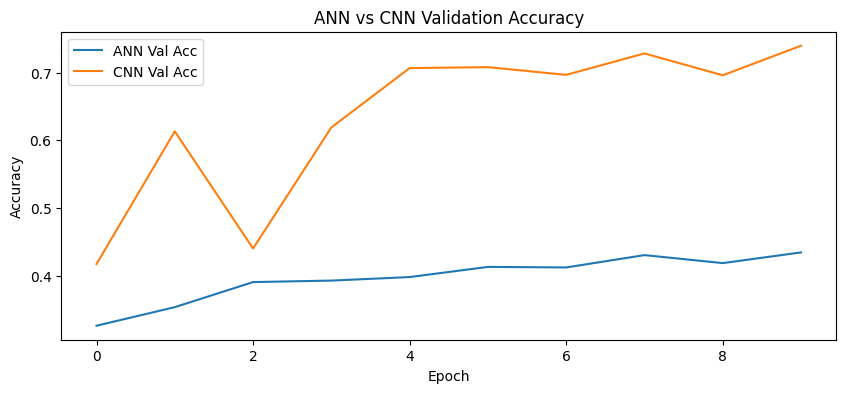

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4397
1,CNN,0.7290


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [13]:
# Increased the  ANN layers and observing the  performance
ann_model_upgraded = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),  # Existing layer
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),  # Added extra layer
    layers.Dense(10, activation='softmax')
])

ann_model_upgraded.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Upgraded ANN...")
ann_history_upgraded = ann_model_upgraded.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# Evaluate performance
ann_upgraded_loss, ann_upgraded_acc = ann_model_upgraded.evaluate(x_test_flat, y_test, verbose=0)
print(u"📊 Upgraded ANN Test Accuracy: {:.2f}%".format(ann_upgraded_acc * 100))

Training Upgraded ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2423 - loss: 2.0449 - val_accuracy: 0.2998 - val_loss: 1.9143
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2923 - loss: 1.9130 - val_accuracy: 0.3364 - val_loss: 1.8770
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3131 - loss: 1.8671 - val_accuracy: 0.3280 - val_loss: 1.8178
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3243 - loss: 1.8342 - val_accuracy: 0.3672 - val_loss: 1.7916
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3328 - loss: 1.8117 - val_accuracy: 0.3900 - val_loss: 1.7460
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3391 - loss: 1.7974 - val_accuracy: 0.3690 - val_loss: 1.7618
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3437 - loss: 1.7877 - val_accuracy: 0.3972 - val_loss: 1.7418
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy:

In [15]:
# Upgraded CNN Model
from tensorflow.keras.callbacks import EarlyStopping

# Define Data Augmentation layers
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Build CNN with progressive filters (32 -> 64 -> 128)
cnn_model_upgraded = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation, # Data Augmentation

    # First Conv Block (32 filters)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Conv Block (64 filters)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third Conv Block (128 filters)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_upgraded.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Task 3: Train up to 20 epochs with the early stopping callback
print("Training Upgraded CNN (with Augmentation & EarlyStopping)...")
cnn_history_upgraded = cnn_model_upgraded.fit(
    x_train_norm, y_train,
    epochs=20,  # Increased epochs to 20
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]  # Added EarlyStopping
)

# Evaluate performance
cnn_upgraded_loss, cnn_upgraded_acc = cnn_model_upgraded.evaluate(x_test_norm, y_test, verbose=0)
print(u"📊 Upgraded CNN Test Accuracy: {:.2f}%".format(cnn_upgraded_acc * 100))

Training Upgraded CNN (with Augmentation & EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 137ms/step - accuracy: 0.4083 - loss: 1.7369 - val_accuracy: 0.5018 - val_loss: 1.4149
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.5164 - loss: 1.3613 - val_accuracy: 0.5846 - val_loss: 1.1796
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.5622 - loss: 1.2408 - val_accuracy: 0.5842 - val_loss: 1.1643
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 137ms/step - accuracy: 0.5964 - loss: 1.1527 - val_accuracy: 0.6148 - val_loss: 1.0917
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.6150 - loss: 1.1030 - val_accuracy: 0.6548 - val_loss: 0.9819
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 141ms/step - accuracy: 0.6279 - loss: 1.0566 - val_accuracy: 0.5870 - val_loss: 1.1979
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.6479 - loss: 1.0114 - val_accuracy: 0.5316 - val_loss: 1.5073
Epoch 8/20
704/704 

In [16]:
# Create a comprehensive comparison table
final_comparison = pd.DataFrame({
    "Model Architecture": [
        "Original ANN",
        "Upgraded ANN (More Layers)",
        "Original CNN",
        "Upgraded CNN (Filters + Augmentation)"
    ],
    "Test Accuracy": [
        ann_test_acc,        # ~0.4397
        ann_upgraded_acc,    # ~0.4083
        cnn_test_acc,        # ~0.7290
        cnn_upgraded_acc     # Will pull from your running cell
    ]
})

# Format accuracy as a clean percentage
final_comparison["Test Accuracy (%)"] = (final_comparison["Test Accuracy"] * 100).round(2).astype(str) + "%"
final_comparison.drop(columns=["Test Accuracy"], inplace=True)

final_comparison

,Model Architecture,Test Accuracy (%)
0,Original ANN,43.97%
1,Upgraded ANN (More Layers),40.83%
2,Original CNN,72.9%
3,Upgraded CNN (Filters + Augmentation),69.27%
